# libs e dados

In [1]:
import pandas as pd
from google.colab import drive

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

In [8]:
drive.mount('/content/drive', force_remount=1)

Mounted at /content/drive


In [10]:
df = pd.read_csv('/content/drive/MyDrive/projeto-integrador-I/data/processed/df.csv')

In [11]:
# numero de notificações por caso (1)
df['N'] = 1
df.head()

,DESC_PERIODO,DESC_SUBTIPOLOCAL,BAIRRO,RUBRICA,MES_ESTATISTICA,ANO_ESTATISTICA,MES,DIA_SEMANA,DIFERENCA_DIAS,N
0,À NOITE,COMÉRCIO E SERVIÇOS,VILA MATIAS,ART. 213 - ESTUPRO,1,2022,JANEIRO,SABADO,46,1
1,DE MADRUGADA,RESIDÊNCIA,MARAPE,ESTUPRO DE VULNERAVEL (ART.217-A),1,2022,JANEIRO,DOMINGO,0,1
2,À NOITE,RESIDÊNCIA,MACUCO,ART. 213 - ESTUPRO,1,2022,JANEIRO,SABADO,1,1
3,EM HORA INCERTA,RESIDÊNCIA,MORRO NOVA CINTRA,ESTUPRO DE VULNERAVEL (ART.217-A),1,2022,JANEIRO,INCERTO,INCERTO,1
4,DE MADRUGADA,VIA PÚBLICA,MACUCO,ART. 213 - ESTUPRO,2,2022,FEVEREIRO,DOMINGO,111,1


# graficos

## distribuição temporal

In [30]:
# coluna datetime auxiliar (2022-1...)
df['ANO-MES'] = pd.to_datetime(df['ANO_ESTATISTICA'].astype(str) + '-' +  df['MES_ESTATISTICA'].astype(str))

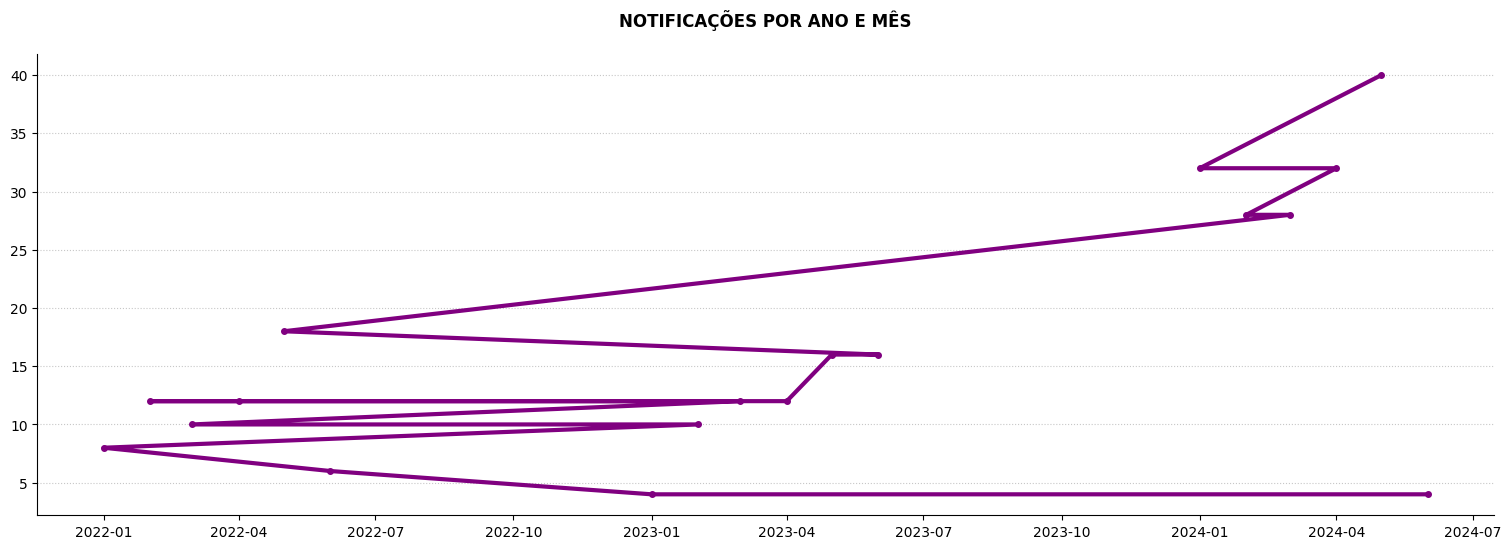

In [27]:
# agrupamento por data
por_data= df.groupby('ANO-MES')['N'].sum().sort_values(ascending=False).reset_index()

# eixos 
data = por_data['ANO-MES']
occ = por_data['N']

# grid geral
fig = plt.figure(figsize=(15, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig)

# grafico 1 (occ x ano/mes)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(data, occ, color='purple', linewidth=3, marker='o', markersize=4)
ax1.set_title('NOTIFICAÇÕES POR ANO E MÊS', fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle=':', alpha=0.7)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

## distribuição por local


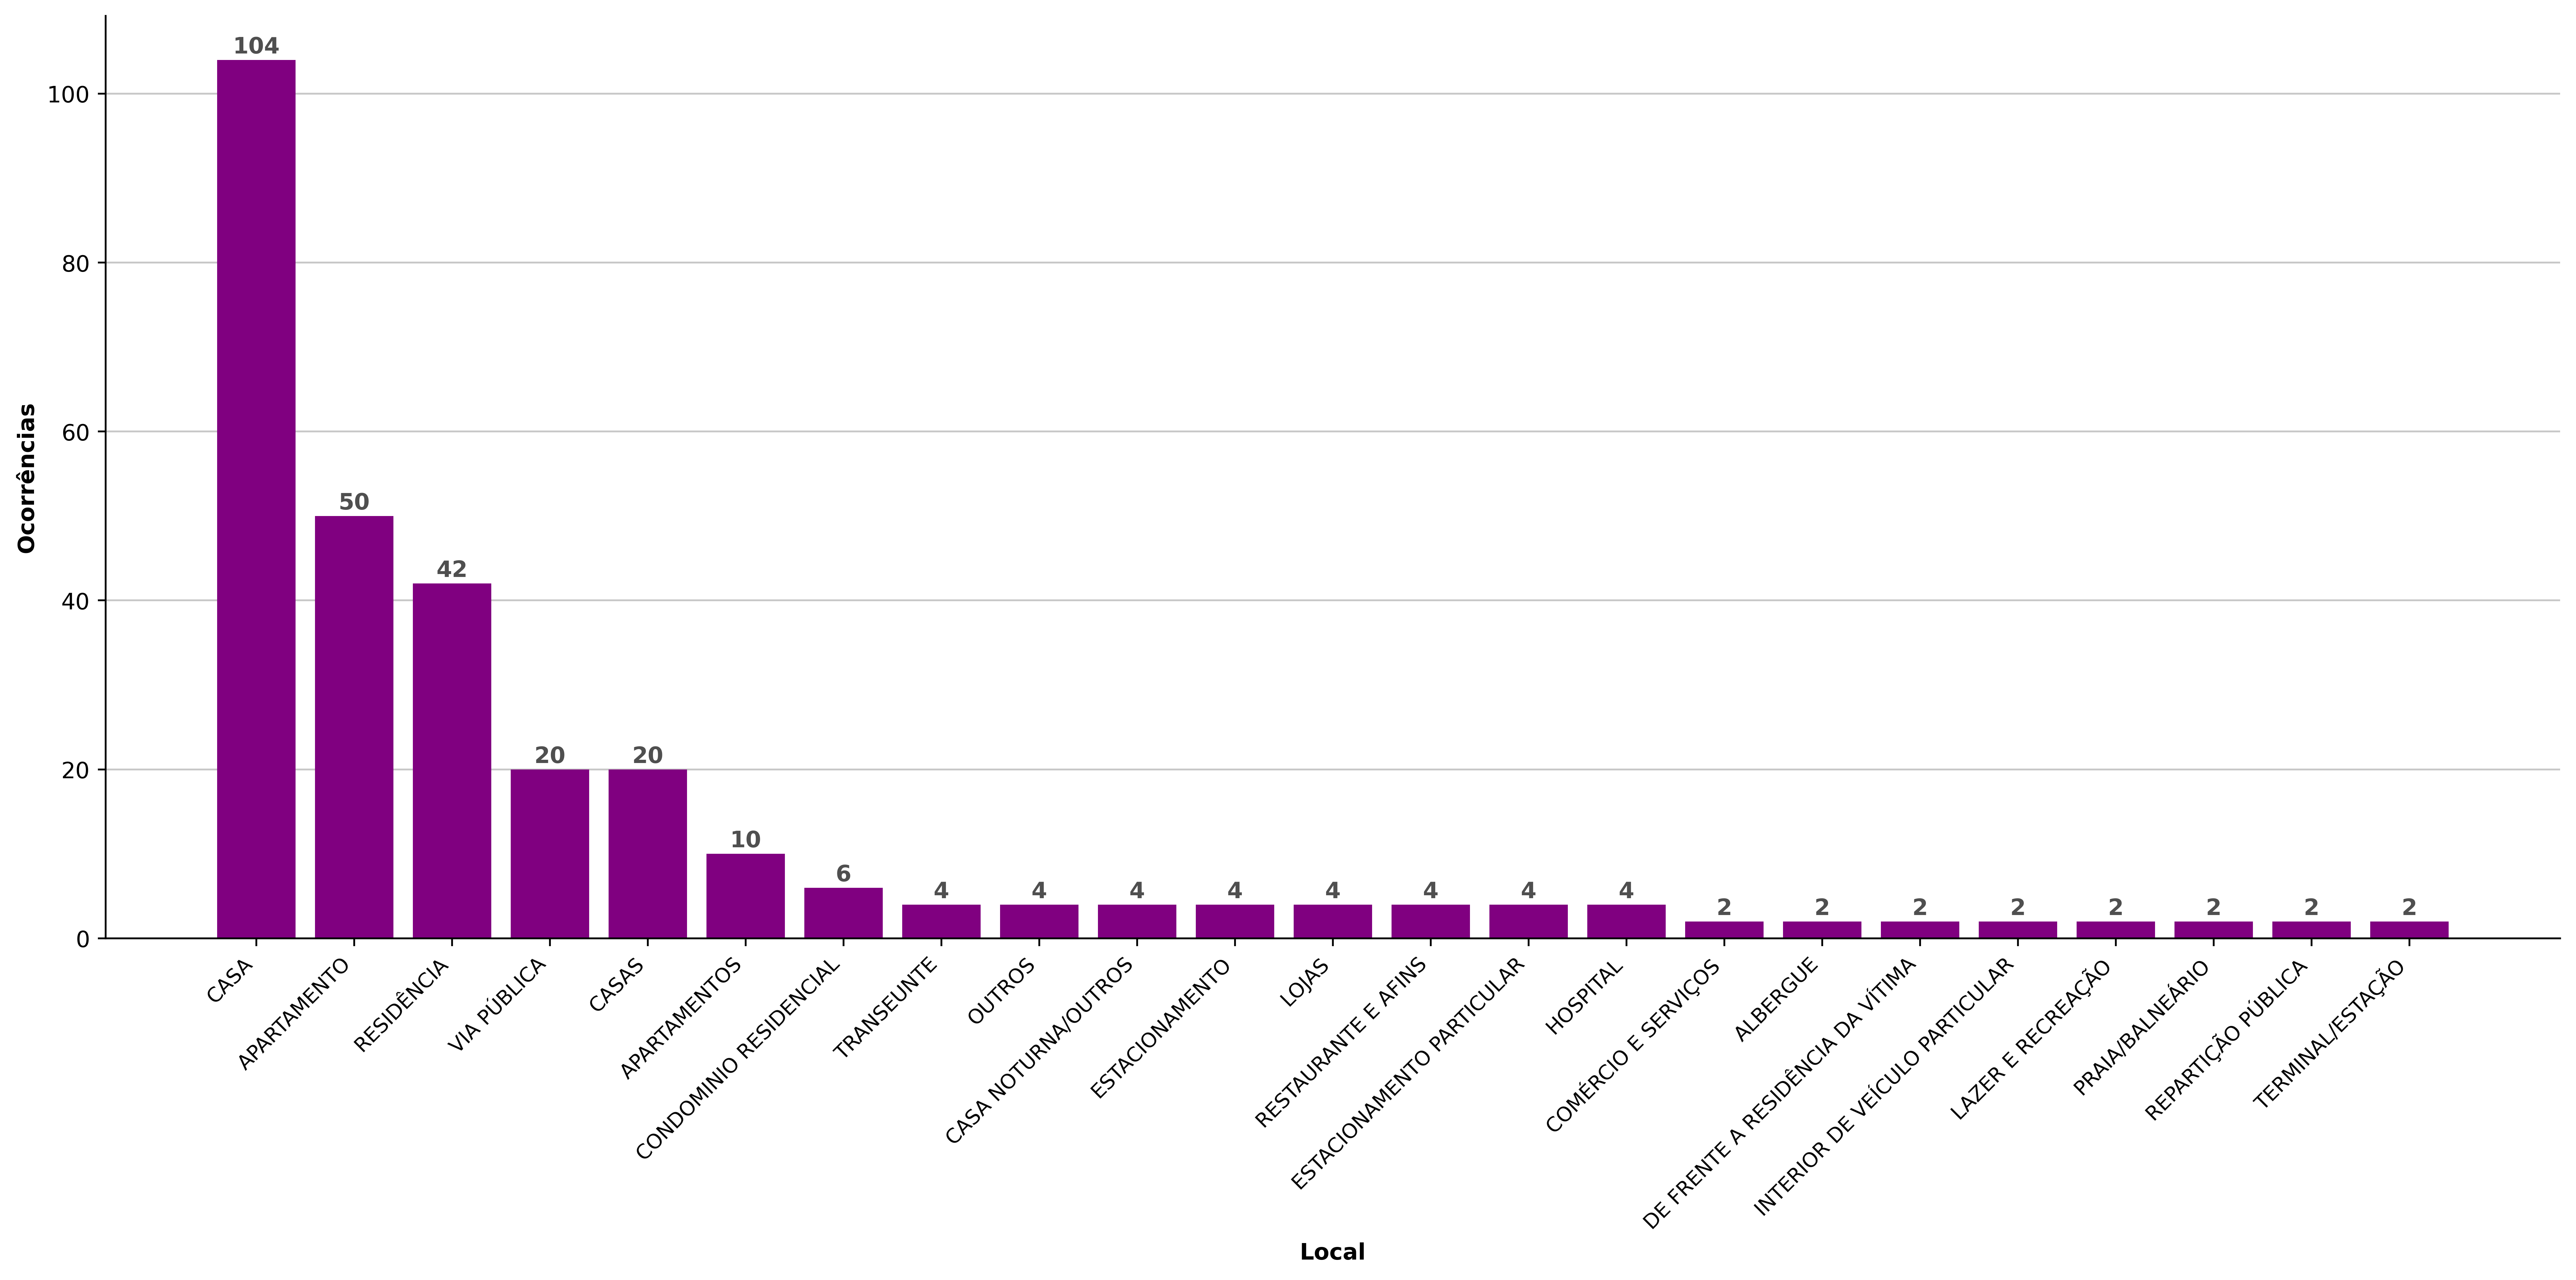

In [102]:
# agrupamento por local
por_local = df.groupby('DESC_SUBTIPOLOCAL')['N'].sum().sort_values(ascending=False).reset_index()

# eixos
local = por_local['DESC_SUBTIPOLOCAL']
occ = por_local['N']

# objeto grafico
fig, ax =  plt.subplots(figsize=(16, 8), dpi=500)
bars = ax.bar(local, occ, color='purple')

# eixos
ax.set_xlabel("Local", fontweight='bold')
ax.set_ylabel("Ocorrências", fontweight='bold')

# ticks e labels
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.bar_label(bars, padding=1, fontweight='bold', color="#000000B0")

# configurações de grid
plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.gca().set_axisbelow(True) 

# remove bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig('/content/drive/MyDrive/projeto-integrador-I/plots/por_local.png')
plt.close(fig)

## distribuição por bairro

In [93]:
# zonas de cada bairro
zonas = {
    # macrozona leste (amarelo - #FFFF00)
    'EMBARE': 'LESTE', 'GONZAGA': 'LESTE', 'APARECIDA': 'LESTE', 
    'MARAPE': 'LESTE', 'BOQUEIRAO': 'LESTE', 'JOSE MENINO': 'LESTE',
    'PONTA DA PRAIA': 'LESTE', 'POMPEIA': 'LESTE', 'ESTUARIO': 'LESTE',

    # macrozona centro (laranja - #E67E22)
    'VILA MATIAS': 'CENTRO', 'CENTRO': 'CENTRO', 'PAQUETA': 'CENTRO',
    'VALONGO': 'CENTRO', 'CHICO DE PAULA': 'CENTRO',

    # macrozona noroeste (salmão - #F1948A)
    'RADIO CLUBE': 'NOROESTE', 'MACUCO': 'NOROESTE', 'CANELEIRA': 'NOROESTE', 
    'AREIA BRANCA': 'NOROESTE', 'CASTELO': 'NOROESTE', 'SABOO': 'NOROESTE', 
    'VILA NOVA': 'NOROESTE', 'CAMPO GRANDE': 'NOROESTE', 'SANTA MARIA': 'NOROESTE',
    'BOM RETIRO': 'NOROESTE', 'VILA SAO JORGE': 'NOROESTE', 'ALEMOA': 'NOROESTE',

    # macrozona morros (verde - #82E0AA)
    'MORRO DO PACHECO': 'MORROS', 'MORRO DE SAO BENTO': 'MORROS', 
    'MORRO NOVA CINTRA': 'MORROS', 'MORRO SANTA MARIA': 'MORROS', 
    'MORRO SAO BENTO': 'MORROS', 'VILA VOTURUA': 'MORROS',

    # desconhecidos (cinza - ##545454)
    'AREA RURAL': 'DESCONHECIDO', 'CARUARA': 'DESCONHECIDO', 
    'SAO JORGE': 'DESCONHECIDO', 'VILA BELMIRO': 'DESCONHECIDO',
    'NAO IDENTIFICADO': 'DESCONHECIDO', 'PORTO MACUCO': 'DESCONHECIDO',
    'PORTO PONTA DA PRAIA': 'DESCONHECIDO', 'QUILOMBO': 'DESCONHECIDO',
    'VILA PROGRESSO': 'DESCONHECIDO', 'MORRO JOSE MENINO': 'DESCONHECIDO'
}


df['MACROZONA'] = df['BAIRRO'].map(zonas)

In [94]:
# agrupamento por bairro
por_bairro = df.groupby(['BAIRRO', 'MACROZONA'])['N'].sum().sort_values(ascending=False).reset_index()


In [95]:
# cores por zona
cores_zona = {
    'LESTE': '#FFFF00',       # amarelo
    'CENTRO': '#E67E22',      # laranja
    'NOROESTE': '#F1948A',    # salmão
    'MORROS': '#82E0AA',      # verde
    'DESCONHECIDO': "#545454" # cinza
}

cores = [cores_zona[zona] for zona in por_bairro['MACROZONA']]

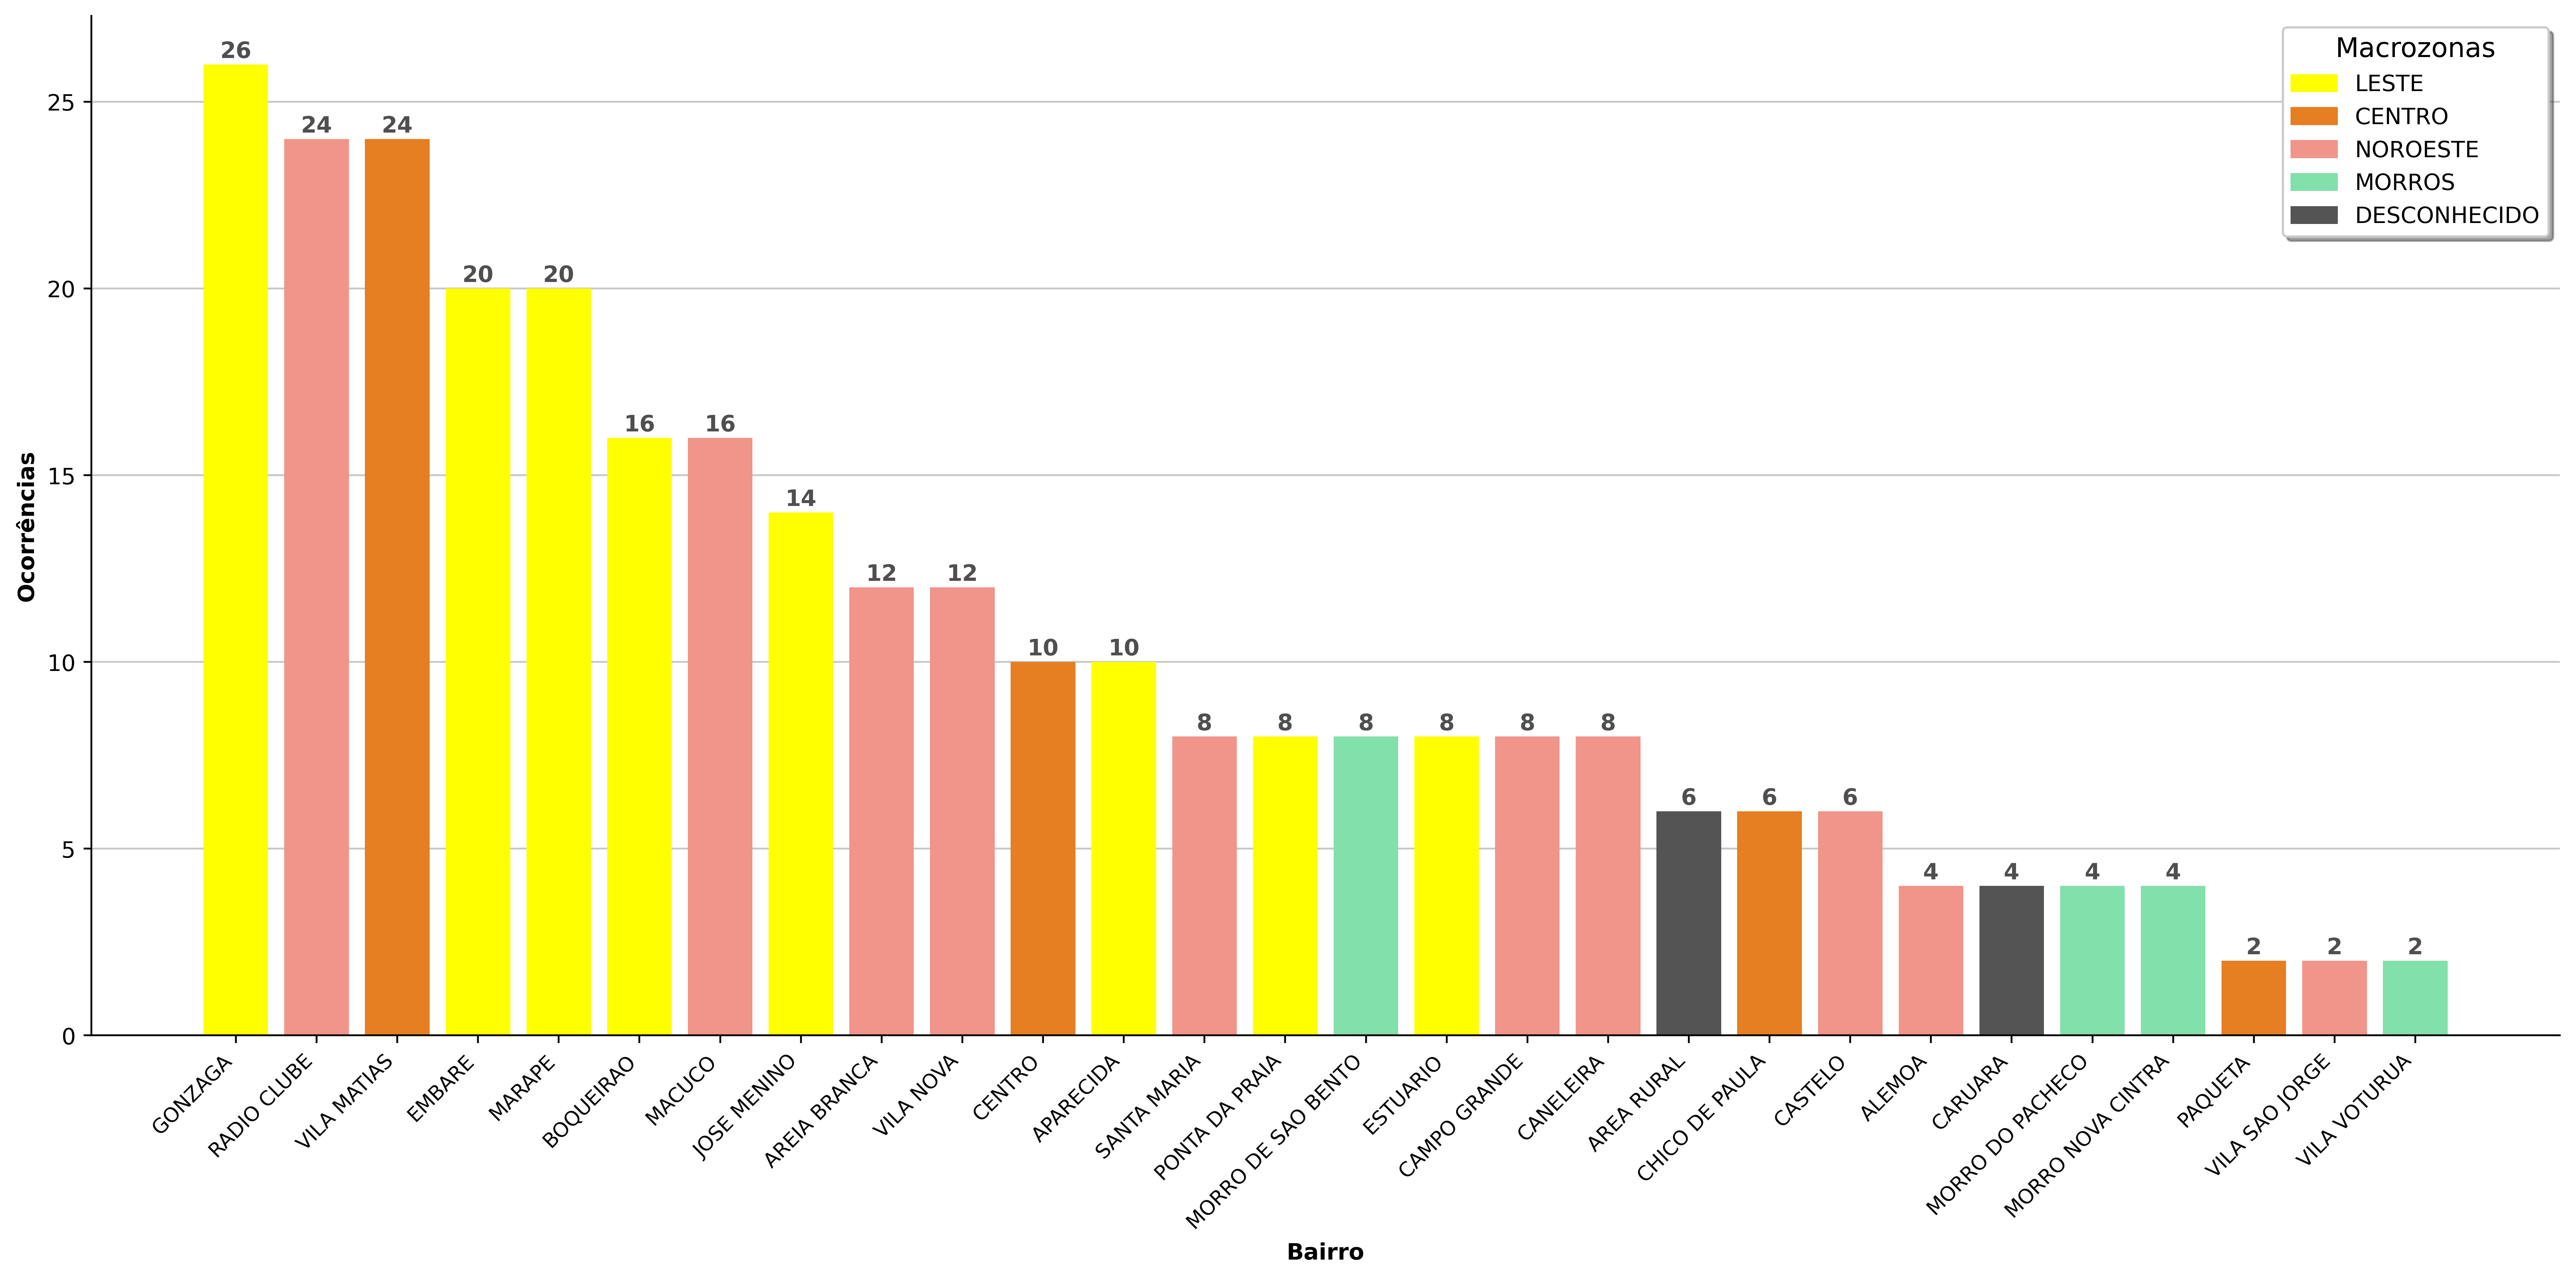

In [103]:
# eixos
local = por_bairro['BAIRRO']
occ = por_bairro['N']

# objeto grafico
fig, ax =  plt.subplots(figsize=(16, 8), dpi=500)
bars = ax.bar(por_bairro['BAIRRO'], por_bairro['N'], color=cores)

#legenda
patches = [mpatches.Patch(color=cor, label=zona) for zona, cor in cores_zona.items()]
ax.legend(handles=patches, title="Macrozonas", title_fontsize='12', 
          fontsize='10', loc='upper right', frameon=True, shadow=True)

# eixos
ax.set_xlabel("Bairro", fontweight='bold')
ax.set_ylabel("Ocorrências", fontweight='bold')

# ticks e labels
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.bar_label(bars, padding=1, fontweight='bold', color="#000000B0")

# configurações de grid
plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.gca().set_axisbelow(True) 

# remove bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig('/content/drive/MyDrive/projeto-integrador-I/plots/por_bairro.png')
plt.close(fig)

## distribuiçao por periodo do dia

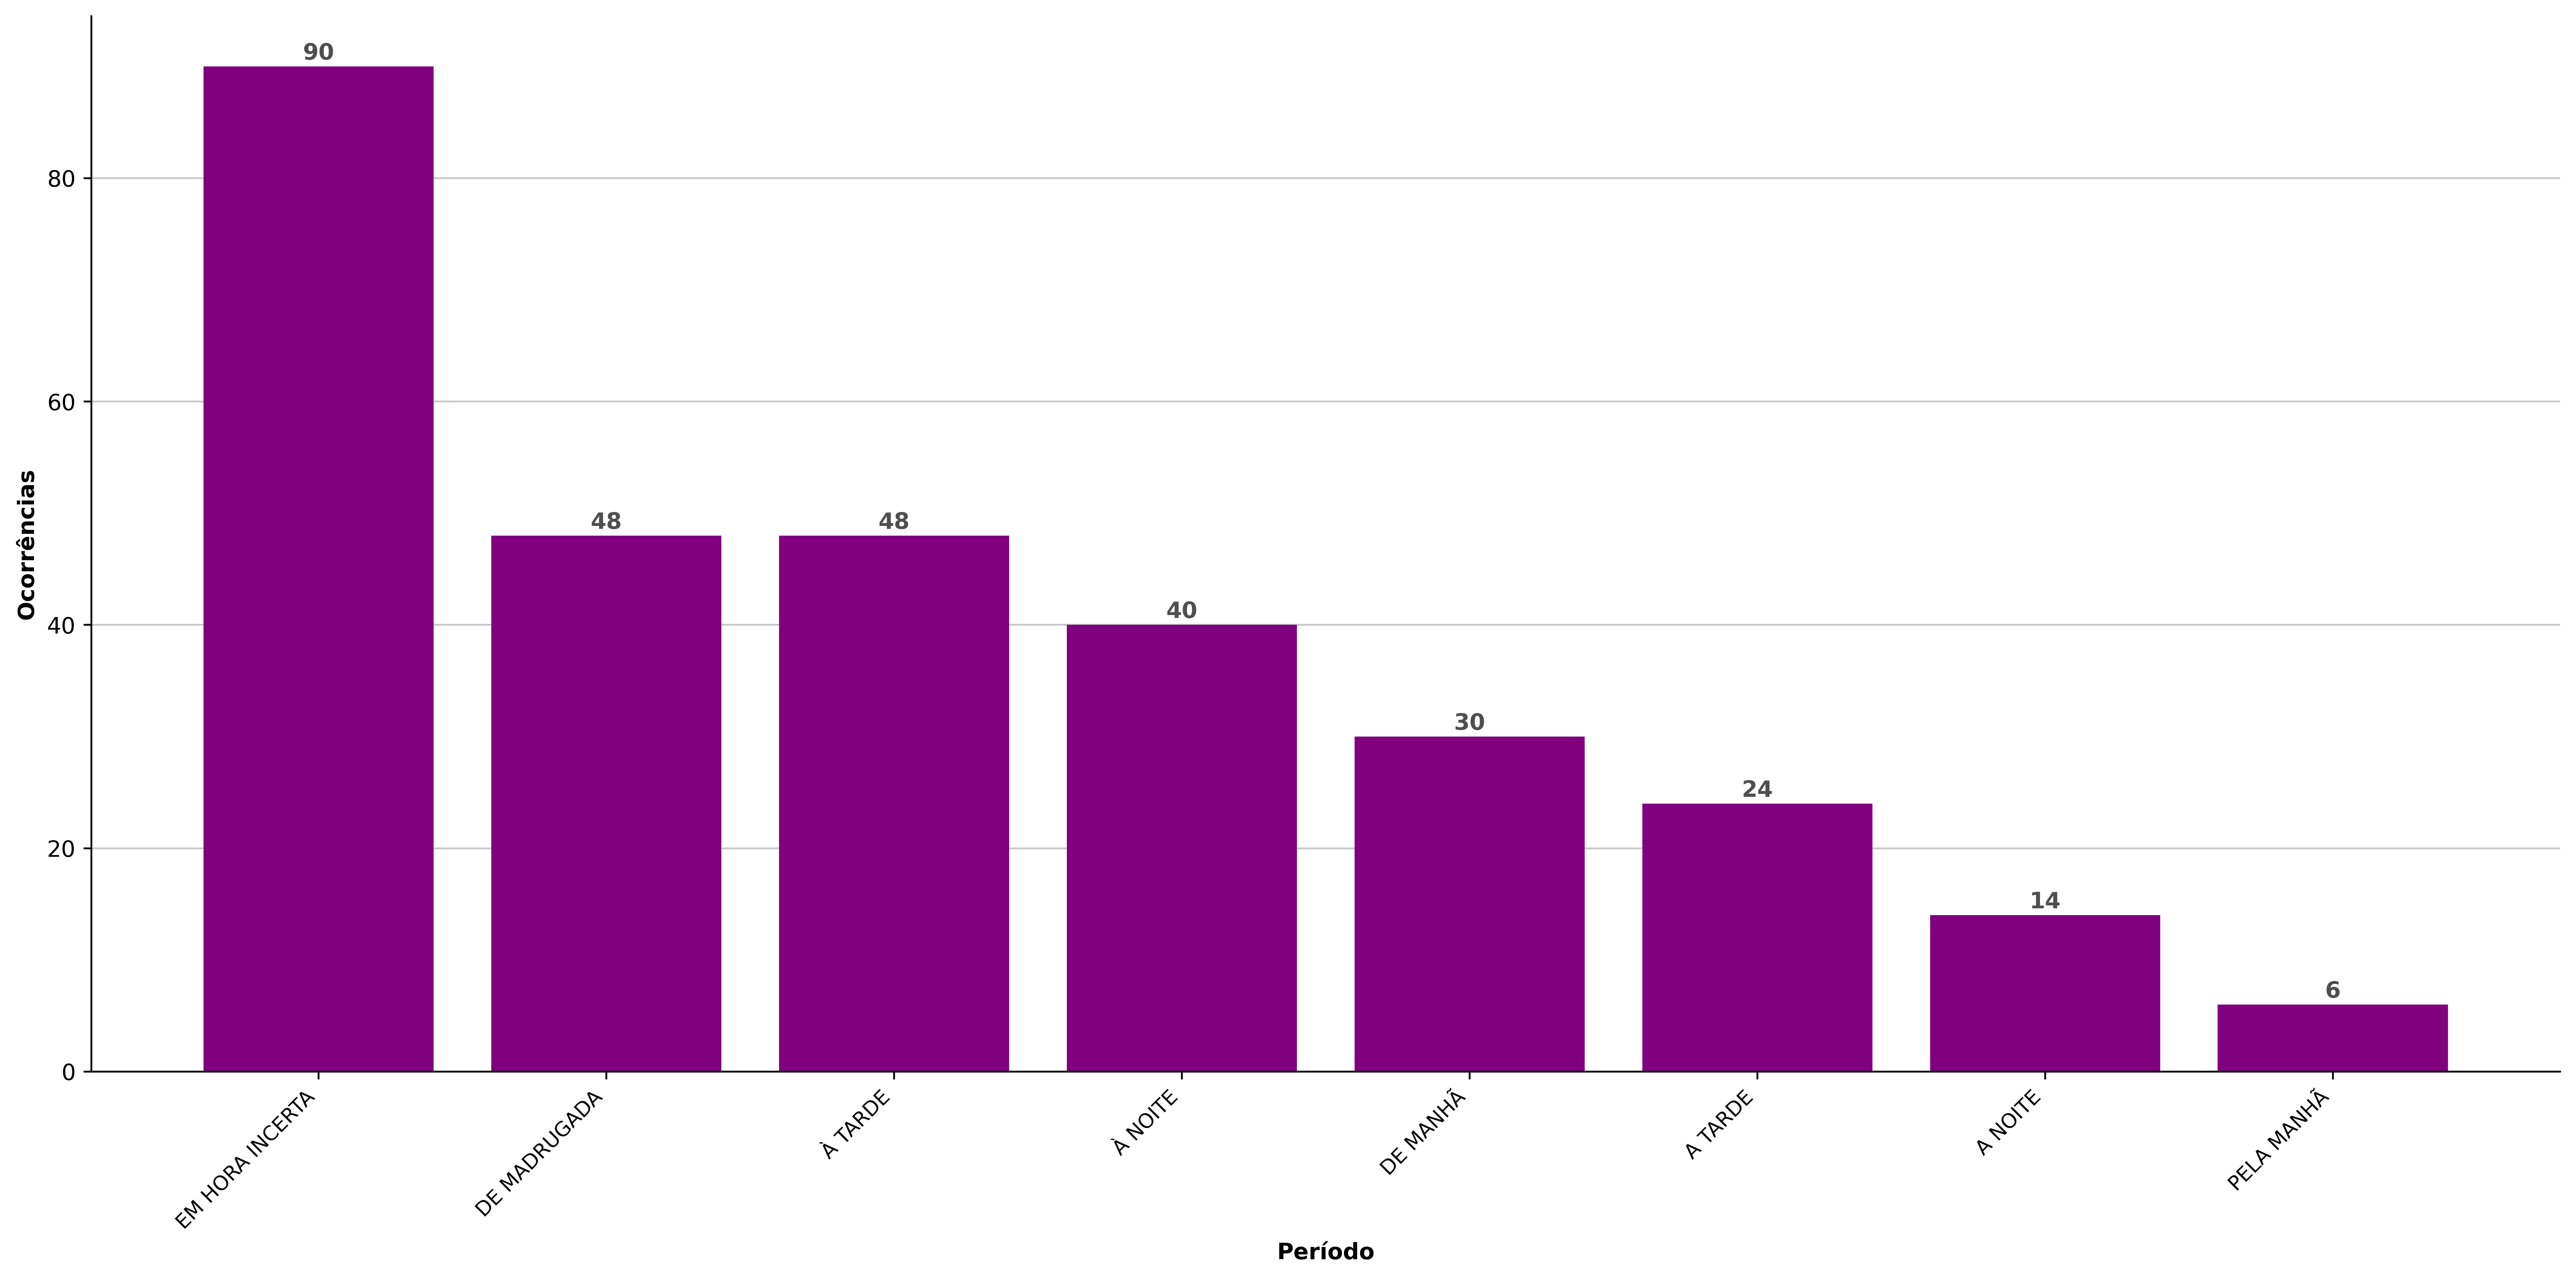

In [104]:
# agrupamento por periodo
por_periodo = df.groupby('DESC_PERIODO')['N'].sum().sort_values(ascending=False).reset_index()

# eixos
local = por_periodo['DESC_PERIODO']
occ = por_periodo['N']

# objeto grafico
fig, ax =  plt.subplots(figsize=(16, 8), dpi=500)
bars = ax.bar(local, occ, color='purple')

# eixos
ax.set_xlabel("Período", fontweight='bold')
ax.set_ylabel("Ocorrências", fontweight='bold')

# ticks e labels
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.bar_label(bars, padding=1, fontweight='bold', color="#000000B0")

# configurações de grid
plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.gca().set_axisbelow(True) 

# remove bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig('/content/drive/MyDrive/projeto-integrador-I/plots/por_periodo.png')
plt.close(fig)